Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

3 premiers pics du diffractogramme XRD :
- Pic 1 : 2θ = 11.67°, Intensité = 3.06%
- Pic 2 : 2θ = 22.26°, Intensité = 0.59%
- Pic 3 : 2θ = 23.28°, Intensité = 49.42%


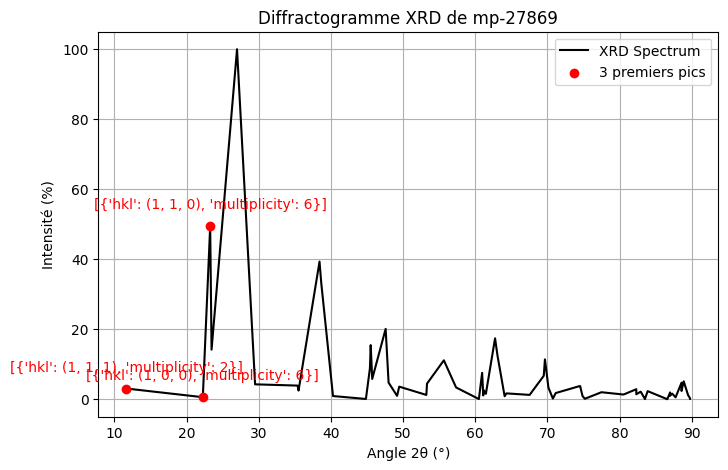

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.ext.matproj import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator

API_KEY = "zA1YwwFoS7C8RQ3ZpVn2lK2ClRoSNTFM"  
material_id = "mp-27869" 

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id)

#diffractogramme XRD avec Cu Kα (λ = 1.54060 Å)
xrd_calc = XRDCalculator(wavelength=1.54060)
pattern = xrd_calc.get_pattern(structure)

#3 premiers pics
peak_angles = pattern.x[:3]  # angles 2θ
peak_intensities = pattern.y[:3]  # Intensités 
peak_hkls = pattern.hkls[:3]  # Indices 

print("3 premiers pics du diffractogramme XRD :")
for i in range(3):
    print(f"- Pic {i+1} : 2θ = {peak_angles[i]:.2f}°, Intensité = {peak_intensities[i]:.2f}%")

#graphe du diffractogramme 
plt.figure(figsize=(8, 5))
plt.plot(pattern.x, pattern.y, color="black", lw=1.5, label="XRD Spectrum")
plt.scatter(peak_angles, peak_intensities, color="red", label="3 premiers pics", zorder=3)


for i in range(3):
    plt.text(peak_angles[i], peak_intensities[i] + 5, f"{peak_hkls[i]}", fontsize=10, ha="center", color="red")

plt.xlabel("Angle 2θ (°)")
plt.ylabel("Intensité (%)")
plt.title(f"Diffractogramme XRD de {material_id}")
plt.legend()
plt.grid(True)
plt.show()


